
===== Fit Result =====
Peak Center         = 637.197155546 nm
FWHM                = 0.000042 nm
Linewidth           = 31.3 MHz
Coherence Time      = 10182.9 ps


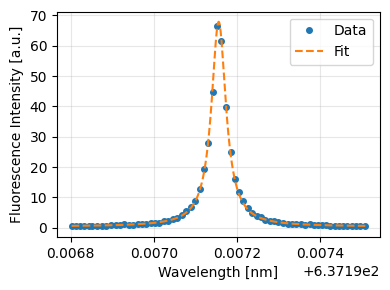

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================
# Load Data
# =========================
file_path = r"C:\Users\oprs1\Measurement\PLE\20260429\PLE_15시34분24초.csv"
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()

wavelength = pd.to_numeric(df["Wavelength"], errors='coerce').to_numpy()
counts = pd.to_numeric(df["count"], errors='coerce').to_numpy()

# NaN 제거
valid = ~np.isnan(wavelength) & ~np.isnan(counts)
wavelength = wavelength[valid]
counts = counts[valid]

# =========================
# Lorentzian Function
# =========================
def lorentzian(x, A, x0, gamma, C):
    gamma = np.abs(gamma)  # linewidth 양수 강제
    return A * (0.5*gamma)**2 / ((x - x0)**2 + (0.5*gamma)**2) + C

# =========================
# Fit Around Target Peak
# =========================
target_peak = 637.197164
fit_window = 0.0005

mask = (wavelength > target_peak - fit_window) & (wavelength < target_peak + fit_window)

x_fit = wavelength[mask]
y_fit = counts[mask]

# Initial Guess
A0 = y_fit.max() - y_fit.min()
x0 = target_peak            
gamma0 = 0.001
C0 = y_fit.min()

# =========================
# Curve Fit (with bounds)
# =========================
popt, _ = curve_fit(
    lorentzian,
    x_fit,
    y_fit,
    p0=[A0, x0, gamma0, C0],
    bounds=(
        [0, target_peak - 0.002, 0, -np.inf],
        [np.inf, target_peak + 0.002, 0.02, np.inf]
    ),
    maxfev=10000
)

A_fit, center_fit, fwhm_fit, C_fit = popt
fwhm_fit = abs(fwhm_fit)

# =========================
# Frequency Linewidth
# =========================
c = 299792458
delta_nu = c * (fwhm_fit * 1e-9) / (center_fit * 1e-9)**2

# Coherence Time
tau_c = 1 / (np.pi * delta_nu)

# =========================
# Print Result
# =========================
print("\n===== Fit Result =====")
print(f"Peak Center         = {center_fit:.9f} nm")
print(f"FWHM                = {fwhm_fit:.6f} nm")
print(f"Linewidth           = {delta_nu/1e6:.1f} MHz")
print(f"Coherence Time      = {tau_c*1e12:.1f} ps")

# =========================
# Plot Fit Result
# =========================
x_dense = np.linspace(x_fit.min(), x_fit.max(), 1000)

plt.figure(figsize=(4,3))
plt.plot(x_fit, y_fit, 'o', ms=4, label='Data')
plt.plot(x_dense, lorentzian(x_dense, *popt), lw=1.5, label='Fit', linestyle='--')

plt.xlabel("Wavelength [nm]")
plt.ylabel("Fluorescence Intensity [a.u.]")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

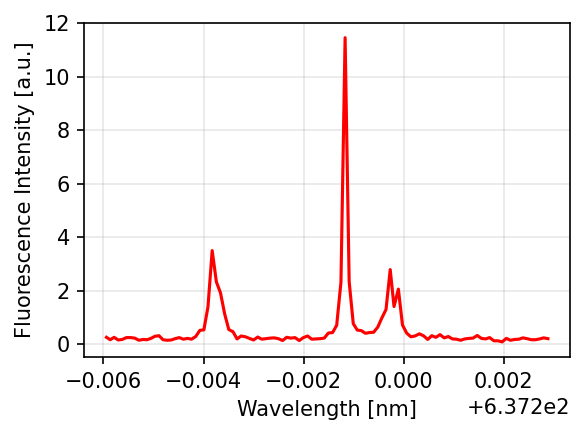

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Load CSV File
# =========================
file_path = r"C:\Users\oprs1\Measurement\PLE\20260318\PLE_19시14분29초.csv"
df = pd.read_csv(file_path)

# 컬럼명 공백 제거
df.columns = df.columns.str.strip()

# 필요한 컬럼 추출
wavelength = pd.to_numeric(df["Wavelength"], errors='coerce')
counts = pd.to_numeric(df["count"], errors='coerce')

# NaN 제거
valid = wavelength.notna() & counts.notna()
wavelength = wavelength[valid]
counts = counts[valid]

# =========================
# Plot Full Spectrum
# =========================
plt.figure(figsize=(4,3), dpi=150)
plt.plot(wavelength, counts, color='red', lw=1.5)

plt.xlabel("Wavelength [nm]")
plt.ylabel("Fluorescence Intensity [a.u.]")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()